# 03 — Feature Engineering

**Girdi:** `data/csv/cleaned_dataset.csv` (02_data_cleaning çıktısı)  
**Çıktılar:**
- `data/csv/featured_dataset.csv` — seçilmiş özellikler + encodlanmış label
- `data/csv/selected_features.txt` — kullanılan özellik listesi (model notebook'ları için)
- `data/csv/label_mapping.csv` — integer ↔ string label eşlemesi

## Bu Notebook'ta Yapılanlar

| Adım | İşlem | Gerekçe |
|------|--------|---------|
| 1 | Dataset yükleme + özet | Baseline |
| 2 | Duplicate sütun tespiti ve silme | CIC-IDS2017 bilinen hatası (R7) |
| 3 | Yüksek korelasyon analizi ve silme | Multicollinearity azaltma |
| 4 | Mutual Information ile feature importance | Model-agnostic, non-linear ilişkileri yakalar |
| 5 | Düşük önem skoru filtresi | Gürültülü özellikleri çıkar |
| 6 | Label encoding (multiclass + binary) | sklearn uyumluluğu |
| 7 | Çarpıklık (skewness) raporu | Modeling notebook için referans |
| 8 | Görselleştirme | Korelasyon haritası + feature importance |
| 9 | Kalite kontrol assert'leri | Sessiz hataları önle |
| 10 | Kaydetme | 04_modeling girdisi |

**Kapsam dışı (04_modeling'e bırakıldı):** Feature scaling, SMOTE/oversampling,
train/test split. Tree-based modeller scaling gerektirmediğinden ve split stratejisi
modelin türüne göre farklılaşabileceğinden bu kararlar modeling notebook'unda alınacak.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings

from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

RANDOM_STATE = 42

# ── Output paths ────────────────────────────────────────────────────────────
PLOT_DIR = "../data/plots/03_features"
os.makedirs(PLOT_DIR, exist_ok=True)

print("=" * 50)
print("Libraries loaded ✓")
print(f"  Pandas   : {pd.__version__}")
print(f"  NumPy    : {np.__version__}")
print(f"  Plot dir : {PLOT_DIR}")
print("=" * 50)


Libraries loaded ✓
  Pandas   : 3.0.1
  NumPy    : 2.4.3
  Plot dir : ../data/plots


## 1. Dataset Yuekleme

In [2]:
INPUT_PATH          = "../data/csv/cleaned_dataset.csv"
OUTPUT_DATASET      = "../data/csv/featured_dataset.csv"
OUTPUT_FEATURES_TXT = "../data/csv/selected_features.txt"
OUTPUT_LABEL_MAP    = "../data/csv/label_mapping.csv"

df = pd.read_csv(INPUT_PATH, low_memory=False)

print("=" * 65)
print("CLEANED DATASET LOADED (02 notebook output)")
print("=" * 65)
print(f"  Rows    : {df.shape[0]:>9,}")
print(f"  Columns : {df.shape[1]}")
print(f"  Memory  : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print()

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
non_numeric  = [c for c in df.columns if c not in numeric_cols]
print(f"  Numeric columns : {len(numeric_cols)}")
print(f"  Non-numeric     : {non_numeric}")
print()
print("Class distribution:")
label_dist = df["Label"].value_counts()
for label, cnt in label_dist.items():
    pct = cnt / len(df) * 100
    print(f"  {label:<40} {cnt:>8,}  ({pct:4.1f}%)")

# ── Track feature counts for before/after comparison ────────────────────────
n_features_initial = len(numeric_cols)
_label_dist_before = df["Label"].value_counts().copy()
print(f"\n[Tracking] Initial numeric features: {n_features_initial}")

# ── Save a fixed sample for model before/after comparison ──────────────────
_MODEL_SAMPLE    = 50_000
_rng_model       = np.random.RandomState(RANDOM_STATE)
_sample_idx      = _rng_model.choice(len(df), size=min(_MODEL_SAMPLE, len(df)), replace=False)
_X_before_sample = df[numeric_cols].values[_sample_idx]   # ALL features, fixed rows
_n_features_all  = len(numeric_cols)
print(f"[Model comparison] Saved {len(_sample_idx):,}-row sample "
      f"({_n_features_all} features) for before/after training comparison.")


CLEANED DATASET LOADED (02 notebook output)
  Rows    :   495,855
  Columns : 72
  Memory  : 335.2 MB

  Numeric columns : 70
  Non-numeric     : ['Label', 'source_file']

Class distribution:
  BENIGN                                    383,341  (77.3%)
  DDoS                                       29,998  ( 6.0%)
  PortScan                                   25,483  ( 5.1%)
  DoS Hulk                                   22,915  ( 4.6%)
  DoS GoldenEye                              10,286  ( 2.1%)
  FTP-Patator                                 5,931  ( 1.2%)
  DoS slowloris                               5,384  ( 1.1%)
  DoS Slowhttptest                            5,228  ( 1.1%)
  SSH-Patator                                 3,219  ( 0.6%)
  Bot                                         1,948  ( 0.4%)
  Web Attack - Brute Force                    1,470  ( 0.3%)
  Web Attack - XSS                              652  ( 0.1%)

[Tracking] Initial numeric features: 70
[Model comparison] Saved 50,000-row

## 2. Duplicate Sutun Tespiti ve Silme

**Gecekce:** CIC-IDS2017'de `Fwd Header Length` ve `Fwd Header Length.1` sutunlari
ozdes degerler icerir (R7 - CICFlowMeter uretim hatasi). Bu tur duplikasyonlar
korelasyon analizini bozar ve modeli o ozelligi iki kez agirliklandirmaya iter.
Duplicate tespiti deger bazinda yapilir; sadece isim benzerligine guvenilmez.

In [3]:
print("=" * 60)
print("DUPLICATE COLUMN DETECTION")
print("=" * 60)

n_before_dup = len(numeric_cols)

# Compare columns by transposing
df_T = df[numeric_cols].T
duplicate_mask = df_T.duplicated(keep="first")
duplicate_cols = df_T[duplicate_mask].index.tolist()
original_cols  = df_T[~duplicate_mask].index.tolist()

if duplicate_cols:
    print(f"Duplicate columns with identical values ({len(duplicate_cols)}):")
    for dup in duplicate_cols:
        for orig in original_cols:
            if df[dup].equals(df[orig]):
                print(f"  '{dup}'  ==  '{orig}'  -> dropping '{dup}'")
                break
    df.drop(columns=duplicate_cols, inplace=True)
    print(f"\n-> {len(duplicate_cols)} duplicate columns dropped. Remaining: {df.shape[1]}")
else:
    print("✓ No duplicate columns found")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
n_after_dup  = len(numeric_cols)
print(f"\nNumeric features: {n_before_dup} → {n_after_dup}  (removed: {n_before_dup - n_after_dup})")

# ── Save top-30 correlation matrix BEFORE high-corr filter (for viz) ────────
_top30_pre_corr = (
    df[numeric_cols].var()
    .sort_values(ascending=False)
    .head(30)
    .index.tolist()
)
_corr_top30_before = df[_top30_pre_corr].corr(method="pearson")
print("[Tracking] Saved pre-filter top-30 correlation matrix for before/after viz.")


DUPLICATE COLUMN DETECTION
Duplicate columns with identical values (7):
  'SYN Flag Count'  ==  'Fwd PSH Flags'  -> dropping 'SYN Flag Count'
  'CWE Flag Count'  ==  'Fwd URG Flags'  -> dropping 'CWE Flag Count'
  'ECE Flag Count'  ==  'RST Flag Count'  -> dropping 'ECE Flag Count'
  'Avg Fwd Segment Size'  ==  'Fwd Packet Length Mean'  -> dropping 'Avg Fwd Segment Size'
  'Fwd Header Length.1'  ==  'Fwd Header Length'  -> dropping 'Fwd Header Length.1'
  'Subflow Fwd Packets'  ==  'Total Fwd Packets'  -> dropping 'Subflow Fwd Packets'
  'Subflow Bwd Packets'  ==  'Total Backward Packets'  -> dropping 'Subflow Bwd Packets'

-> 7 duplicate columns dropped. Remaining: 65

Numeric features: 70 → 63  (removed: 7)
[Tracking] Saved pre-filter top-30 correlation matrix for before/after viz.


## 3. Yuksek Korelasyon Analizi ve Silme

**Akademik gececke:** Pearson korelasyonu |r| > 0.98 olan ozellik ciftlerinden biri
kaldirilir (greedy: once gelen tutulur). Bu esik RFC (2019) ve benzeri IDS
calismalarinda yaygin kullanilir.
- 0.95: Daha agresif, bilgi kaybi riski artar
- **0.98: Asiri bilgi kaybi olmaksizin cok dogrusal bagimliligi kirar (tercihimiz)**
- 0.99: Cok muhafazakar, redundant ozellikler kalabilir

Yontem: ust ucgen korelasyon matrisinde esigi asan ciftleri bul, greedy olarak
ikinci sutunu drop listesine ekle.

In [4]:
CORR_THRESHOLD = 0.98

print("=" * 60)
print(f"HIGH CORRELATION ANALYSIS (threshold: |r| > {CORR_THRESHOLD})")
print("=" * 60)

corr_matrix = df[numeric_cols].corr(method="pearson").abs()

# Upper triangle (excluding diagonal)
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find pairs above threshold
high_corr_pairs = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > CORR_THRESHOLD
]

# Greedy drop list
to_drop_corr = set()
for col1, col2, r in sorted(high_corr_pairs, key=lambda x: -x[2]):
    if col1 not in to_drop_corr and col2 not in to_drop_corr:
        to_drop_corr.add(col2)

print(f"High-correlation pairs found : {len(high_corr_pairs)}")
print(f"Columns to drop              : {len(to_drop_corr)}")
print()

if high_corr_pairs:
    print(f"  {'Kept':<35} {'Dropped':<35} {'r':>6}")
    print("-" * 80)
    shown = set()
    for col1, col2, r in sorted(high_corr_pairs, key=lambda x: -x[2])[:25]:
        if col2 in to_drop_corr:
            kept, dropped = col1, col2
        elif col1 in to_drop_corr:
            kept, dropped = col2, col1
        else:
            continue
        key = (kept, dropped)
        if key not in shown:
            print(f"  {kept:<35} {dropped:<35} {r:.4f}")
            shown.add(key)
    if len(high_corr_pairs) > 25:
        print(f"  ... ({len(high_corr_pairs)} pairs total, first 25 shown)")


HIGH CORRELATION ANALYSIS (threshold: |r| > 0.98)
High-correlation pairs found : 20
Columns to drop              : 14

  Kept                                Dropped                                  r
--------------------------------------------------------------------------------
  Avg Bwd Segment Size                Bwd Packet Length Mean              1.0000
  Subflow Bwd Bytes                   Total Length of Bwd Packets         1.0000
  Subflow Fwd Bytes                   Total Length of Fwd Packets         1.0000
  Bwd Header Length                   Fwd Header Length                   1.0000
  Total Backward Packets              Total Fwd Packets                   0.9995
  Total Length of Bwd Packets         Total Backward Packets              0.9986
  Subflow Bwd Bytes                   Total Backward Packets              0.9986
  Fwd IAT Total                       Flow Duration                       0.9982
  Average Packet Size                 Packet Length Mean               

In [5]:
before_corr = df.shape[1]
df.drop(columns=list(to_drop_corr), inplace=True)
after_corr  = df.shape[1]

numeric_cols  = df.select_dtypes(include=[np.number]).columns.tolist()
n_after_corr  = len(numeric_cols)

print(f"Columns: {before_corr} → {after_corr}  ({before_corr - after_corr} dropped)")
print(f"Remaining numeric features: {n_after_corr}")


Columns: 65 → 51  (14 dropped)
Remaining numeric features: 49


SIGNED CORRELATION ANALYSIS

POSITIVE high correlation (r > 0.5): 72 pairs
→ These features move in the SAME direction.
  (e.g. packet size ↑, flow size ↑)

NEGATIVE high correlation (r < -0.5): 0 pairs
→ These features move in OPPOSITE directions.
  (e.g. packet rate ↑, packet duration ↓)



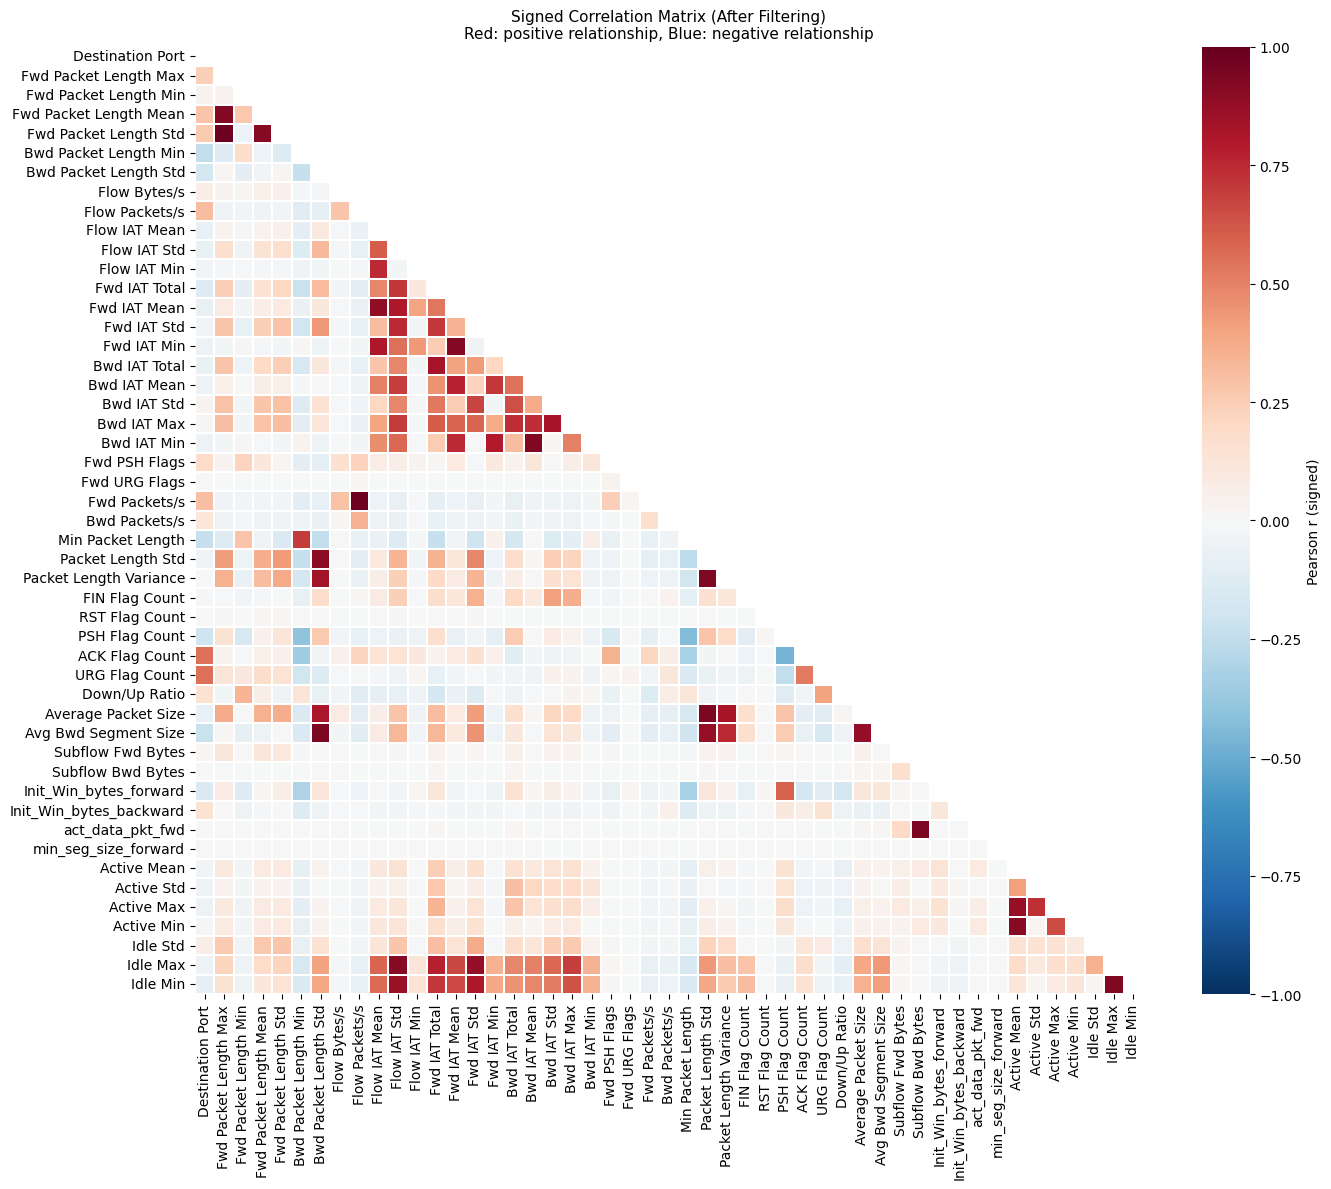

✓ Signed correlation heatmap saved.

✓ No strong negative correlation (r < -0.5) — typical for CIC-IDS2017.
  Most features are either positively correlated or independent.


In [7]:
# ── Signed Correlation Analysis ─────────────────────────────────────────────
print("=" * 70)
print("SIGNED CORRELATION ANALYSIS")
print("=" * 70)

corr_signed = df[numeric_cols].corr(method="pearson")

upper_signed = corr_signed.where(
    np.triu(np.ones(corr_signed.shape), k=1).astype(bool)
)

pos_pairs = [(c, r, upper_signed.loc[r, c])
             for c in upper_signed.columns
             for r in upper_signed.index
             if pd.notna(upper_signed.loc[r, c])
             and upper_signed.loc[r, c] > 0.5]

neg_pairs = [(c, r, upper_signed.loc[r, c])
             for c in upper_signed.columns
             for r in upper_signed.index
             if pd.notna(upper_signed.loc[r, c])
             and upper_signed.loc[r, c] < -0.5]

print(f"\nPOSITIVE high correlation (r > 0.5): {len(pos_pairs)} pairs")
print("→ These features move in the SAME direction.")
print("  (e.g. packet size ↑, flow size ↑)\n")

print(f"NEGATIVE high correlation (r < -0.5): {len(neg_pairs)} pairs")
print("→ These features move in OPPOSITE directions.")
print("  (e.g. packet rate ↑, packet duration ↓)\n")

if len(numeric_cols) <= 50:
    fig, ax = plt.subplots(figsize=(14, 12))
    mask = np.triu(np.ones_like(corr_signed.loc[numeric_cols, numeric_cols], dtype=bool))
    sns.heatmap(
        corr_signed.loc[numeric_cols, numeric_cols],
        mask=mask,
        cmap="RdBu_r",
        center=0,
        vmin=-1, vmax=1,
        annot=False,
        ax=ax,
        linewidths=0.3,
        cbar_kws={"label": "Pearson r (signed)"}
    )
    ax.set_title(
        "Signed Correlation Matrix (After Filtering)\n"
        "Red: positive relationship, Blue: negative relationship",
        fontsize=11
    )
    plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/signed_correlation_heatmap.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print("✓ Signed correlation heatmap saved.")

if neg_pairs:
    print("\nNegatively correlated pairs:")
    for c1, c2, r in sorted(neg_pairs, key=lambda x: x[2])[:10]:
        print(f"  {c1:<35} ↕ {c2:<35}  r={r:.4f}")
else:
    print("\n✓ No strong negative correlation (r < -0.5) — typical for CIC-IDS2017.")
    print("  Most features are either positively correlated or independent.")


## 4. Mutual Information ile Feature Importance

**Akademik gececke:** Mutual Information (MI), ozellik ile hedef degisken arasindaki
bagimliligi dogrusal olmayan iliskileri de kapsayacak sekilde oelcer.
Pearson korelasyonuna kiyasla ag trafikindeki non-linear oruntuleri
(DoS burst, port scan sirasi) daha iyi yakalar.
Model-agnostic oldugu icin Random Forest, XGBoost veya MLP gibi farkli modeller
icin ortak bir temel feature siralamasini saglar.

**Uygulama:** `sklearn.feature_selection.mutual_info_classif`
Buyuk datasette hesap suresi yonetimi icin ornekleme uygulanir.

In [8]:
# MI hesabi icin label'i gecici encode et
le_temp = LabelEncoder()
y_encoded = le_temp.fit_transform(df["Label"])

# Buyuk datasette MI hesabi yavas olabilir -> ornekle
MI_SAMPLE = 100_000
if len(df) > MI_SAMPLE:
    rng = np.random.RandomState(RANDOM_STATE)
    idx = rng.choice(len(df), size=MI_SAMPLE, replace=False)
    X_mi = df[numeric_cols].values[idx]
    y_mi = y_encoded[idx]
    print(f"MI hesabi icin {MI_SAMPLE:,} satir orneklendi (toplam: {len(df):,})")
else:
    X_mi = df[numeric_cols].values
    y_mi = y_encoded
    print(f"MI hesabi tum {len(df):,} satir uzerinde yapiliyor")

print("MI hesaplaniyor... (bu biraz surebilir)")
mi_scores = mutual_info_classif(
    X_mi, y_mi,
    discrete_features=False,
    random_state=RANDOM_STATE
)

mi_df = pd.DataFrame({
    "feature" : numeric_cols,
    "mi_score": mi_scores
}).sort_values("mi_score", ascending=False).reset_index(drop=True)

print()
print("=" * 60)
print("MUTUAL INFORMATION -- ILK 20 OZELLIK")
print("=" * 60)
print(f"  {'#':<4} {'Ozellik':<45} {'MI Skoru':>10}")
print("-" * 65)
for i, row in mi_df.head(20).iterrows():
    print(f"  {i+1:<4} {row['feature']:<45} {row['mi_score']:>10.4f}")

print()
print("=" * 60)
print("EN DUSUK MI SKORLU OZELLIKLER (son 15)")
print("=" * 60)
for i, row in mi_df.tail(15).iterrows():
    print(f"  {i+1:<4} {row['feature']:<45} {row['mi_score']:>10.4f}")

MI hesabi icin 100,000 satir orneklendi (toplam: 495,855)
MI hesaplaniyor... (bu biraz surebilir)

MUTUAL INFORMATION -- ILK 20 OZELLIK
  #    Ozellik                                         MI Skoru
-----------------------------------------------------------------
  1    Average Packet Size                               0.7282
  2    Packet Length Std                                 0.6983
  3    Packet Length Variance                            0.6972
  4    Subflow Fwd Bytes                                 0.6369
  5    Subflow Bwd Bytes                                 0.6290
  6    Avg Bwd Segment Size                              0.6260
  7    Fwd Packet Length Max                             0.5905
  8    Init_Win_bytes_backward                           0.5554
  9    Fwd IAT Total                                     0.5407
  10   Init_Win_bytes_forward                            0.5356
  11   Fwd Packet Length Mean                            0.5331
  12   Fwd IAT Mean           

## 5. Dusuk MI Skor Filtresi

**Gececke:** MI skoru 0.01'in altinda olan ozellikler label ile istatistiksel olarak
bagimsizdir. Bu ozellikleri tutmak model karmasikligini arttirir, egitim suresini
uzatir ve overfitting riskini yukseltir.

Esik 0.01 pratik bir sinirdir (MI dagiliminin alt %5 kuyrugunun kesilmesi).
Hocanin yonlendirmesiyle daha katı/gevşek bir esik uygulanabilir.

In [9]:
MI_THRESHOLD = 0.01

low_mi_features = mi_df[mi_df["mi_score"] < MI_THRESHOLD]["feature"].tolist()

print("=" * 60)
print(f"LOW MI FILTER (threshold: MI < {MI_THRESHOLD})")
print("=" * 60)

if low_mi_features:
    print(f"Removed features ({len(low_mi_features)}):")
    for f in low_mi_features:
        score = mi_df.loc[mi_df["feature"] == f, "mi_score"].values[0]
        print(f"  - {f:<45} MI={score:.5f}")
    df.drop(columns=low_mi_features, inplace=True)
    print(f"\n-> {len(low_mi_features)} features dropped.")
else:
    print(f"✓ No features with MI < {MI_THRESHOLD}")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
n_after_mi   = len(numeric_cols)
print(f"\nRemaining numeric features: {n_after_mi}")


LOW MI FILTER (threshold: MI < 0.01)
Removed features (2):
  - RST Flag Count                                MI=0.00164
  - Fwd URG Flags                                 MI=0.00065

-> 2 features dropped.

Remaining numeric features: 47


## 6. Label Encoding

Iki ayri label sutunu olusturulur:

| Sutun | Aciklama | Kullanim |
|-------|----------|----------|
| `label_multiclass` | 0-N integer (LabelEncoder sirasi) | Cok sinifli siniflandirma |
| `label_binary` | 0=BENIGN, 1=ATTACK | Binary / anomaly detection |

Orijinal `Label` string sutunu korunur (aciklama ve hata analizi icin).

In [10]:
# Multiclass encoding
le = LabelEncoder()
df["label_multiclass"] = le.fit_transform(df["Label"])

# Esleme tablosu
label_mapping = pd.DataFrame({
    "label_int"   : range(len(le.classes_)),
    "label_string": le.classes_
})

# Binary encoding
df["label_binary"] = (df["Label"] != "BENIGN").astype(int)

print("=" * 55)
print("LABEL ENCODING")
print("=" * 55)
print()
print("Multiclass esleme (label_int -> label_string):")
for _, row in label_mapping.iterrows():
    cnt = (df["label_multiclass"] == row["label_int"]).sum()
    pct = cnt / len(df) * 100
    print(f"  {row['label_int']:>2}  ->  {row['label_string']:<40} {cnt:>8,}  (%{pct:4.1f})")

print()
n_benign_bin = (df["label_binary"] == 0).sum()
n_attack_bin = (df["label_binary"] == 1).sum()
print("Binary esleme (label_binary):")
print(f"  0  ->  BENIGN   {n_benign_bin:>9,}  (%{n_benign_bin/len(df)*100:.1f})")
print(f"  1  ->  ATTACK   {n_attack_bin:>9,}  (%{n_attack_bin/len(df)*100:.1f})")

LABEL ENCODING

Multiclass esleme (label_int -> label_string):
   0  ->  BENIGN                                    383,341  (%77.3)
   1  ->  Bot                                         1,948  (% 0.4)
   2  ->  DDoS                                       29,998  (% 6.0)
   3  ->  DoS GoldenEye                              10,286  (% 2.1)
   4  ->  DoS Hulk                                   22,915  (% 4.6)
   5  ->  DoS Slowhttptest                            5,228  (% 1.1)
   6  ->  DoS slowloris                               5,384  (% 1.1)
   7  ->  FTP-Patator                                 5,931  (% 1.2)
   8  ->  PortScan                                   25,483  (% 5.1)
   9  ->  SSH-Patator                                 3,219  (% 0.6)
  10  ->  Web Attack - Brute Force                    1,470  (% 0.3)
  11  ->  Web Attack - XSS                              652  (% 0.1)

Binary esleme (label_binary):
  0  ->  BENIGN     383,341  (%77.3)
  1  ->  ATTACK     112,514  (%22.7)


## 7. Çarpıklık (Skewness) Raporu — Bilgi Amaçlı

**Gececke:** Ag trafikinde paket boyutlari ve zaman araliklari cogunlukla saga carpik
dagilim gosterir (cok sayida kisa akis, az sayida uzun akis). Bu durum:
- **Tree-based modeller** (RF, XGBoost): Scaling ve carpiklik duzeltme gerekmez
- **SVM, KNN, MLP**: StandardScaler veya log1p donusumu onerilir

Bu adim sadece raporlar. Donusum karari 04_modeling'de model seciminden sonra alinir.

ÇARPIKLIK RAPORU -- SADECE BİLGİ (bu adimda donum yapilmaz)
  Yuksek carpiklik (|skew| > 10)       : 13 ozellik
  Orta carpiklik   (2 < |skew| <= 10)  : 31 ozellik
  Dusuk carpiklik  (|skew| <= 2)        : 3 ozellik

NOT: MLP/SVM kullanilacaksa log1p donusumu yuksek carpiklikli ozellikler
     icin 04_modeling'de uygulanmalidir.

  Ozellik                                         Skewness
----------------------------------------------------------
  min_seg_size_forward                             -681.74
  Subflow Fwd Bytes                                 628.84
  act_data_pkt_fwd                                  326.79
  Subflow Bwd Bytes                                 294.98
  Flow Bytes/s                                       46.57
  Active Min                                         27.20
  Active Mean                                        22.44
  Active Std                                         21.91
  Bwd Packets/s                                      21.05
  Flow IAT Min     

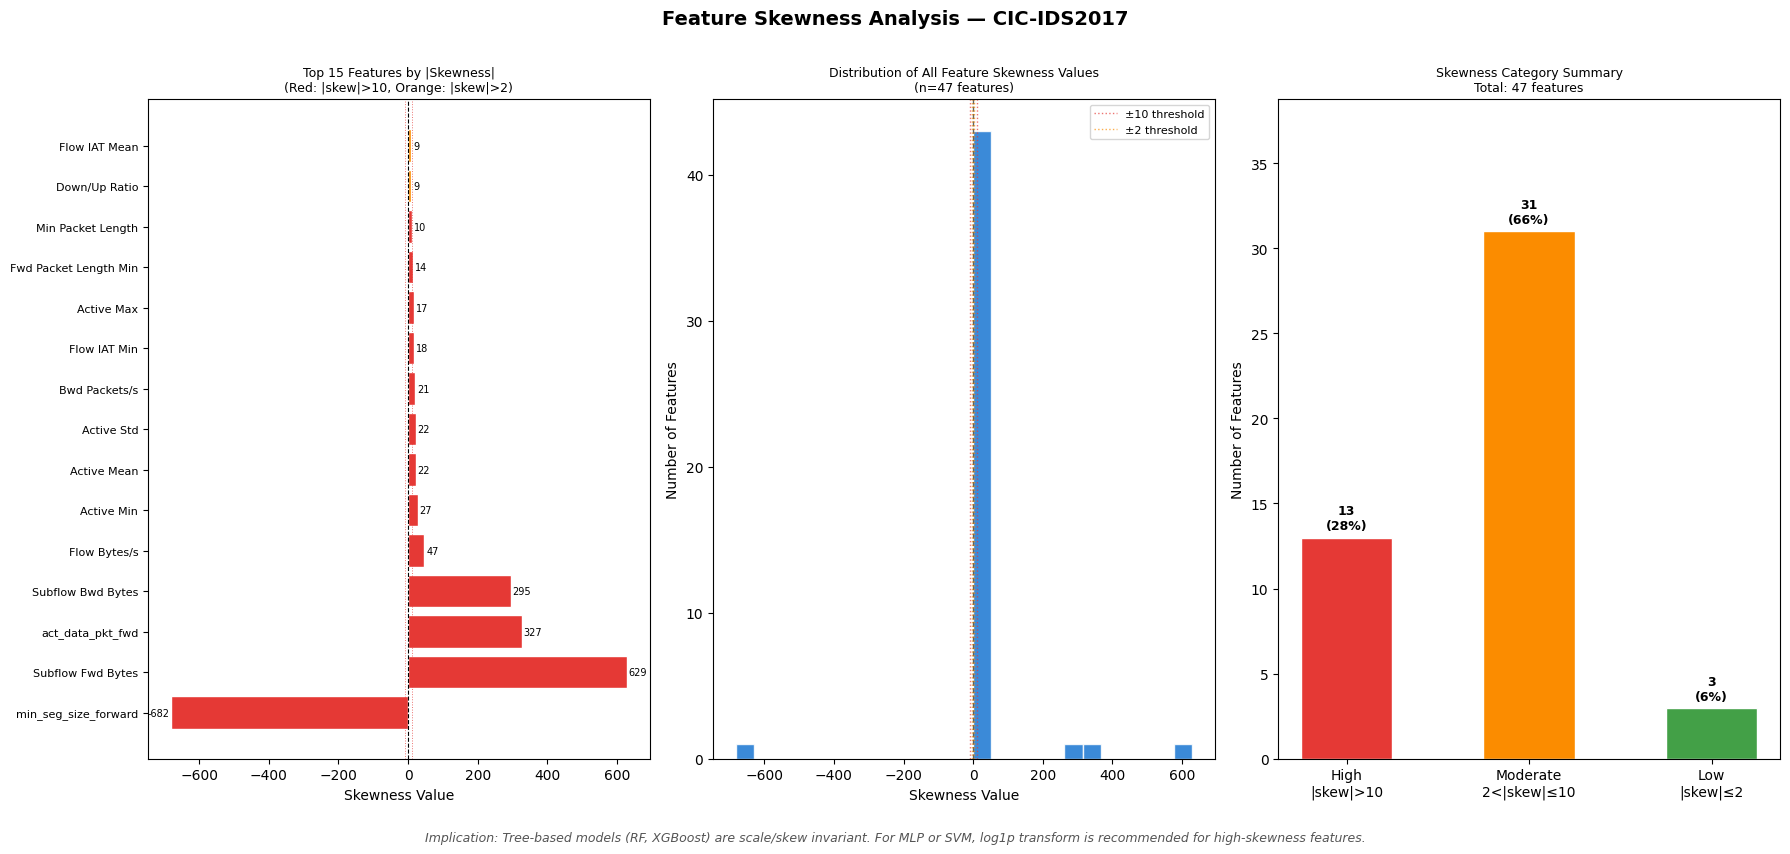

✓ Skewness plot saved: ../data/plots/skewness_plot.png


In [11]:
feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in ("label_multiclass", "label_binary")]

skew_series = df[feature_cols].skew().sort_values(ascending=False)
high_skew   = skew_series[skew_series.abs() > 10].sort_values(key=abs, ascending=False)
mod_skew    = skew_series[(skew_series.abs() > 2) & (skew_series.abs() <= 10)]
low_skew    = skew_series[skew_series.abs() <= 2]

print("=" * 70)
print("ÇARPIKLIK RAPORU -- SADECE BİLGİ (bu adimda donum yapilmaz)")
print("=" * 70)
print(f"  Yuksek carpiklik (|skew| > 10)       : {len(high_skew)} ozellik")
print(f"  Orta carpiklik   (2 < |skew| <= 10)  : {len(mod_skew)} ozellik")
print(f"  Dusuk carpiklik  (|skew| <= 2)        : {len(low_skew)} ozellik")
print()
print("NOT: MLP/SVM kullanilacaksa log1p donusumu yuksek carpiklikli ozellikler")
print("     icin 04_modeling'de uygulanmalidir.")
print()

if len(high_skew) > 0:
    print(f"  {'Ozellik':<45} {'Skewness':>10}")
    print("-" * 58)
    for feat, skv in high_skew.head(15).items():
        print(f"  {feat:<45} {skv:>10.2f}")
    if len(high_skew) > 15:
        print(f"  ... ({len(high_skew)} ozellik toplam, ilk 15 gosterildi)")
        
# ── Skewness Visualization (English) ────────────────────────────────────────
feature_cols_skew = [c for c in df.select_dtypes(include=[np.number]).columns
                     if c not in ("label_multiclass", "label_binary")]

skew_series = df[feature_cols_skew].skew().sort_values(key=abs, ascending=False)

# Categorize
high_skew = skew_series[skew_series.abs() > 10]
mod_skew  = skew_series[(skew_series.abs() > 2) & (skew_series.abs() <= 10)]
low_skew  = skew_series[skew_series.abs() <= 2]

print("=" * 70)
print("SKEWNESS REPORT  (transformation applied only in modeling notebook)")
print("=" * 70)
print(f"  High skewness (|skew| > 10)      : {len(high_skew):>3} features")
print(f"  Moderate skewness (2 < |skew| ≤ 10): {len(mod_skew):>3} features")
print(f"  Low skewness (|skew| ≤ 2)          : {len(low_skew):>3} features")
print()
print("NOTE: For MLP/SVM, apply log1p transform to high-skewness features in 04_modeling.")

# ── Figure layout: 3 panels ──────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 8))
fig.suptitle("Feature Skewness Analysis — CIC-IDS2017",
             fontsize=14, fontweight="bold", y=1.01)

# ── Panel 1: Top 15 most skewed (by |skew|) ──────────────────────────────────
ax1 = fig.add_subplot(1, 3, 1)
top15 = skew_series.head(15)
colors_bar = ["#E53935" if abs(v) > 10 else "#FB8C00" for v in top15.values]
bars = ax1.barh(range(len(top15)), top15.values, color=colors_bar, edgecolor="white")
ax1.set_yticks(range(len(top15)))
ax1.set_yticklabels(top15.index, fontsize=8)
ax1.axvline(0,   color="black",   linewidth=0.8, linestyle="--")
ax1.axvline(10,  color="#E53935", linewidth=0.7, linestyle=":",  alpha=0.7)
ax1.axvline(-10, color="#E53935", linewidth=0.7, linestyle=":",  alpha=0.7)
ax1.set_xlabel("Skewness Value")
ax1.set_title("Top 15 Features by |Skewness|\n"
              "(Red: |skew|>10, Orange: |skew|>2)", fontsize=9)
# Value labels on bars
for bar, val in zip(bars, top15.values):
    xpos = bar.get_width() + (5 if val >= 0 else -5)
    ha   = "left" if val >= 0 else "right"
    ax1.text(xpos, bar.get_y() + bar.get_height() / 2,
             f"{val:.0f}", va="center", ha=ha, fontsize=7)

# ── Panel 2: Histogram of all skewness values ─────────────────────────────────
ax2 = fig.add_subplot(1, 3, 2)
ax2.hist(skew_series.values, bins=25, color="#1976D2",
         edgecolor="white", alpha=0.85)
ax2.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.6)
ax2.axvline(10,  color="#E53935", linewidth=1, linestyle=":", alpha=0.7,
            label="±10 threshold")
ax2.axvline(-10, color="#E53935", linewidth=1, linestyle=":", alpha=0.7)
ax2.axvline(2,   color="#FB8C00", linewidth=1, linestyle=":", alpha=0.7,
            label="±2 threshold")
ax2.axvline(-2,  color="#FB8C00", linewidth=1, linestyle=":", alpha=0.7)
ax2.set_xlabel("Skewness Value")
ax2.set_ylabel("Number of Features")
ax2.set_title("Distribution of All Feature Skewness Values\n"
              f"(n={len(skew_series)} features)", fontsize=9)
ax2.legend(fontsize=8)

# ── Panel 3: Category summary bar ────────────────────────────────────────────
ax3 = fig.add_subplot(1, 3, 3)
categories  = ["High\n|skew|>10", "Moderate\n2<|skew|≤10", "Low\n|skew|≤2"]
cat_counts  = [len(high_skew), len(mod_skew), len(low_skew)]
cat_colors  = ["#E53935", "#FB8C00", "#43A047"]
bars3 = ax3.bar(categories, cat_counts, color=cat_colors,
                edgecolor="white", width=0.5)
for bar, cnt in zip(bars3, cat_counts):
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3,
             f"{cnt}\n({cnt/len(skew_series)*100:.0f}%)",
             ha="center", va="bottom", fontsize=9, fontweight="bold")
ax3.set_ylabel("Number of Features")
ax3.set_title("Skewness Category Summary\n"
              f"Total: {len(skew_series)} features", fontsize=9)
ax3.set_ylim(0, max(cat_counts) * 1.25)
ax3.axhline(0, color="black", linewidth=0.5)

# ── Implication note ─────────────────────────────────────────────────────────
fig.text(0.5, -0.03,
         "Implication: Tree-based models (RF, XGBoost) are scale/skew invariant. "
         "For MLP or SVM, log1p transform is recommended for high-skewness features.",
         ha="center", fontsize=9, style="italic", color="#555555")

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/skewness_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Skewness plot saved: {PLOT_DIR}/skewness_plot.png")

## 8. Gorselletirme

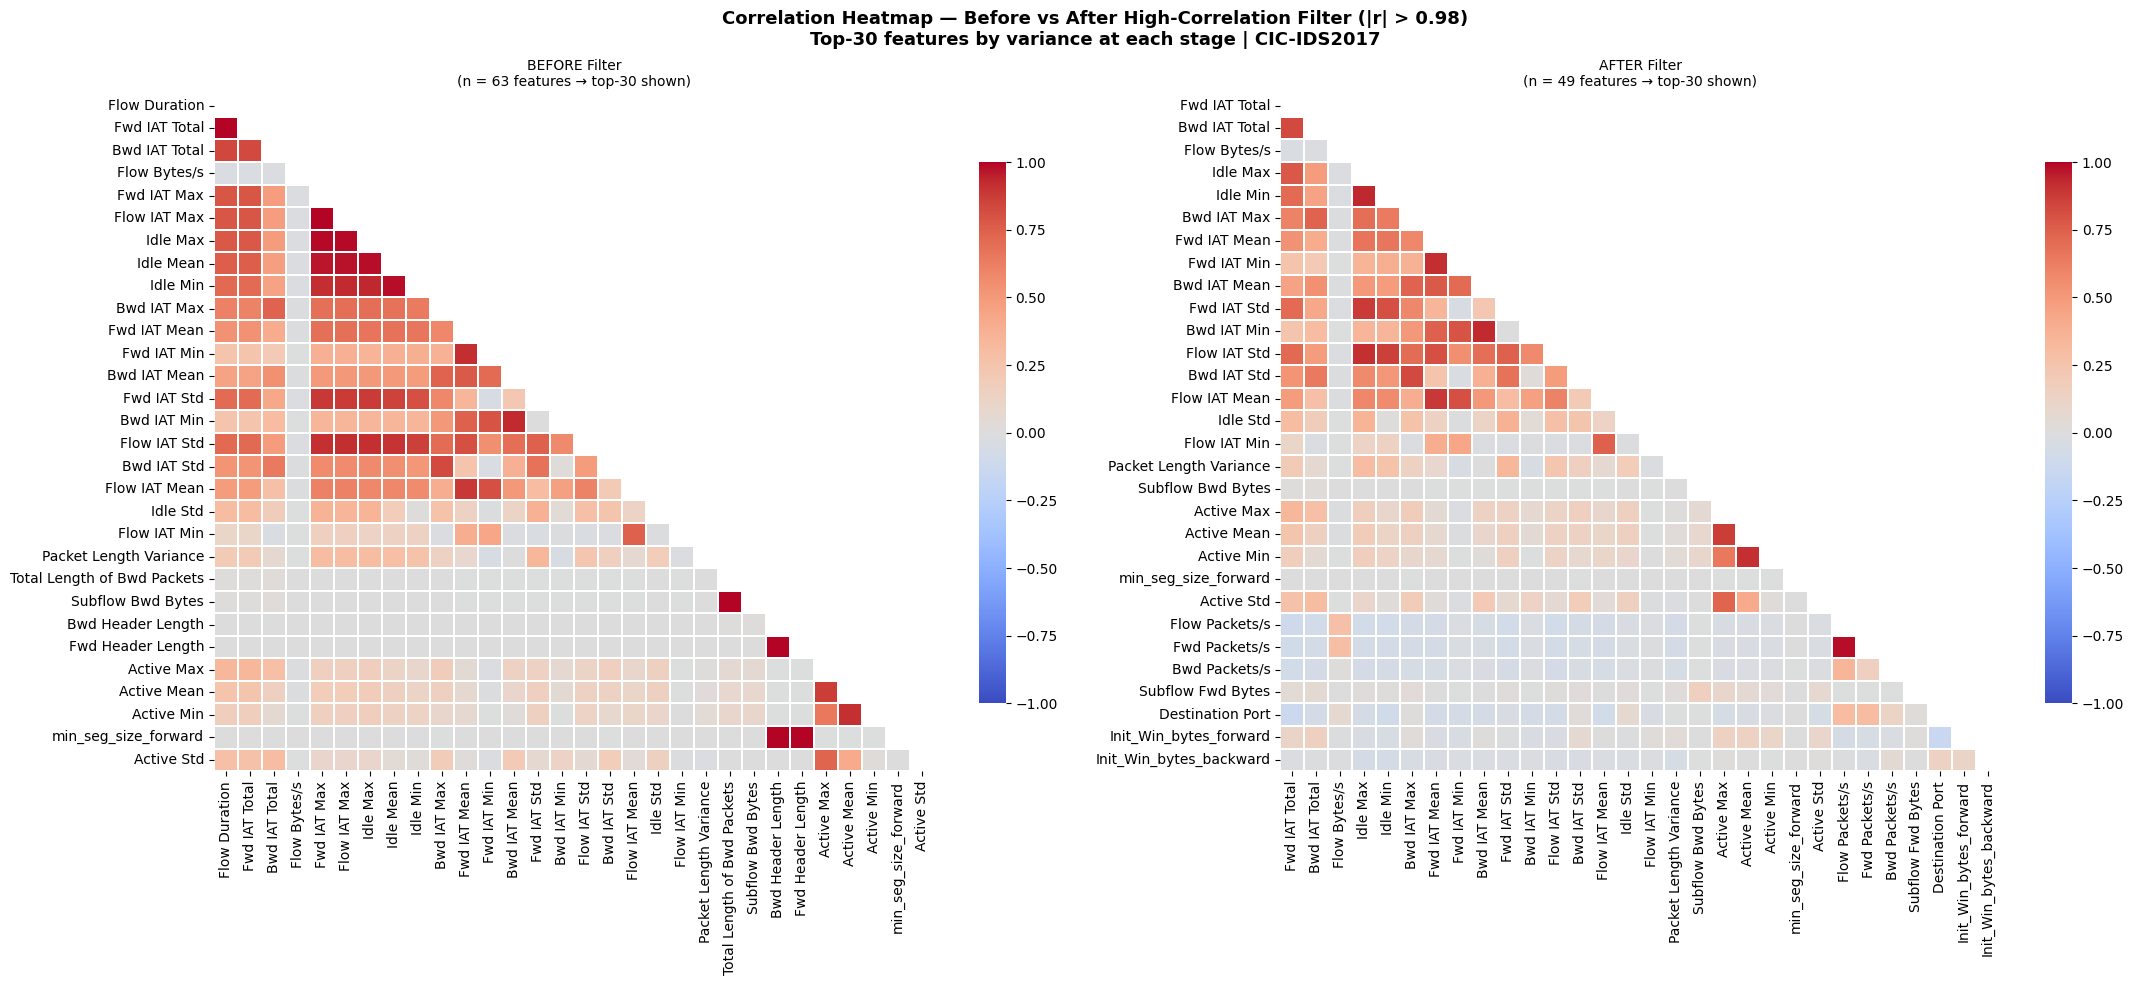

✓ Before/After correlation heatmap saved: ../data/plots/correlation_heatmap_before_after.png


In [12]:
# 8a. Correlation Heatmap — Before vs After High-Correlation Filter
# Left panel: top-30 by variance BEFORE filter (saved in Step 2)
# Right panel: top-30 by variance AFTER filter

feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in ("label_multiclass", "label_binary")]

top30_after = (
    df[feature_cols].var()
    .sort_values(ascending=False)
    .head(30)
    .index.tolist()
)
corr_top30_after = df[top30_after].corr(method="pearson")

fig, axes = plt.subplots(1, 2, figsize=(22, 10))
fig.suptitle(
    f"Correlation Heatmap — Before vs After High-Correlation Filter (|r| > {CORR_THRESHOLD})\n"
    "Top-30 features by variance at each stage | CIC-IDS2017",
    fontsize=13, fontweight="bold"
)

# ── Left: BEFORE ─────────────────────────────────────────────────────────────
ax = axes[0]
mask_before = np.triu(np.ones_like(_corr_top30_before, dtype=bool))
sns.heatmap(
    _corr_top30_before, mask=mask_before,
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    linewidths=0.2, annot=False, ax=ax, cbar_kws={"shrink": 0.8}
)
ax.set_title(
    f"BEFORE Filter\n"
    f"(n = {n_after_dup} features → top-30 shown)",
    fontsize=10
)

# ── Right: AFTER ─────────────────────────────────────────────────────────────
ax = axes[1]
mask_after = np.triu(np.ones_like(corr_top30_after, dtype=bool))
sns.heatmap(
    corr_top30_after, mask=mask_after,
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    linewidths=0.2, annot=False, ax=ax, cbar_kws={"shrink": 0.8}
)
ax.set_title(
    f"AFTER Filter\n"
    f"(n = {n_after_corr} features → top-30 shown)",
    fontsize=10
)

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/correlation_heatmap_before_after.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Before/After correlation heatmap saved: {PLOT_DIR}/correlation_heatmap_before_after.png")


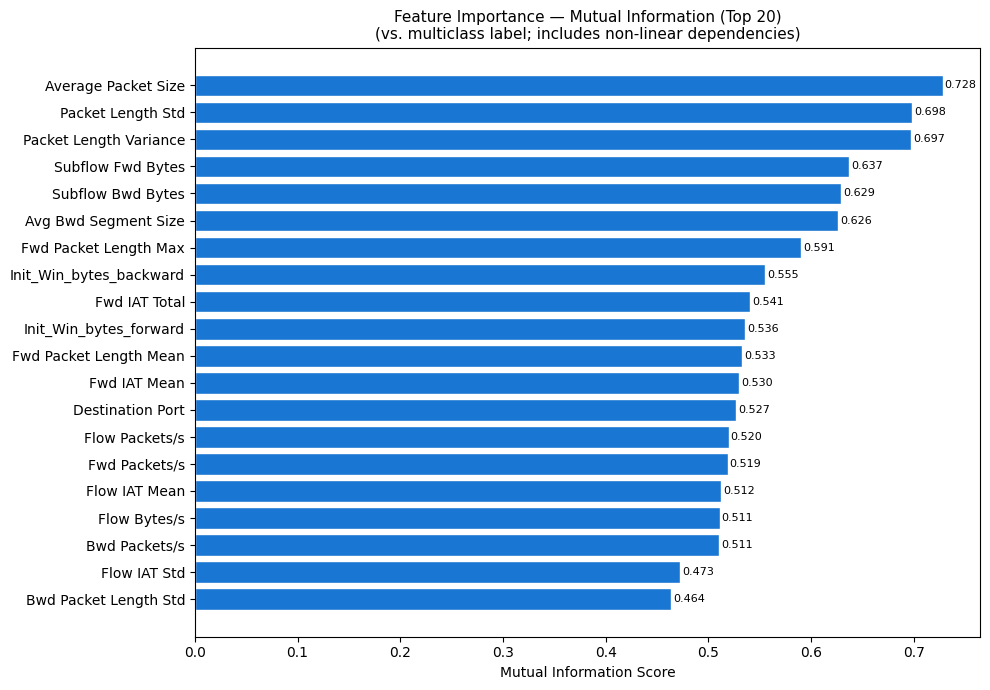

✓ Feature importance plot saved: ../data/plots/feature_importance_mi.png


In [13]:
# 8b. Feature Importance — Mutual Information (Top 20)

mi_df_filtered = mi_df[mi_df["feature"].isin(feature_cols)].copy()
top20_mi = mi_df_filtered.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    top20_mi["feature"][::-1],
    top20_mi["mi_score"][::-1],
    color="#1976D2", edgecolor="white"
)
ax.set_xlabel("Mutual Information Score")
ax.set_title(
    "Feature Importance — Mutual Information (Top 20)\n"
    "(vs. multiclass label; includes non-linear dependencies)",
    fontsize=11
)
for bar, val in zip(bars, top20_mi["mi_score"][::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", ha="left", fontsize=8)

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/feature_importance_mi.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Feature importance plot saved: {PLOT_DIR}/feature_importance_mi.png")


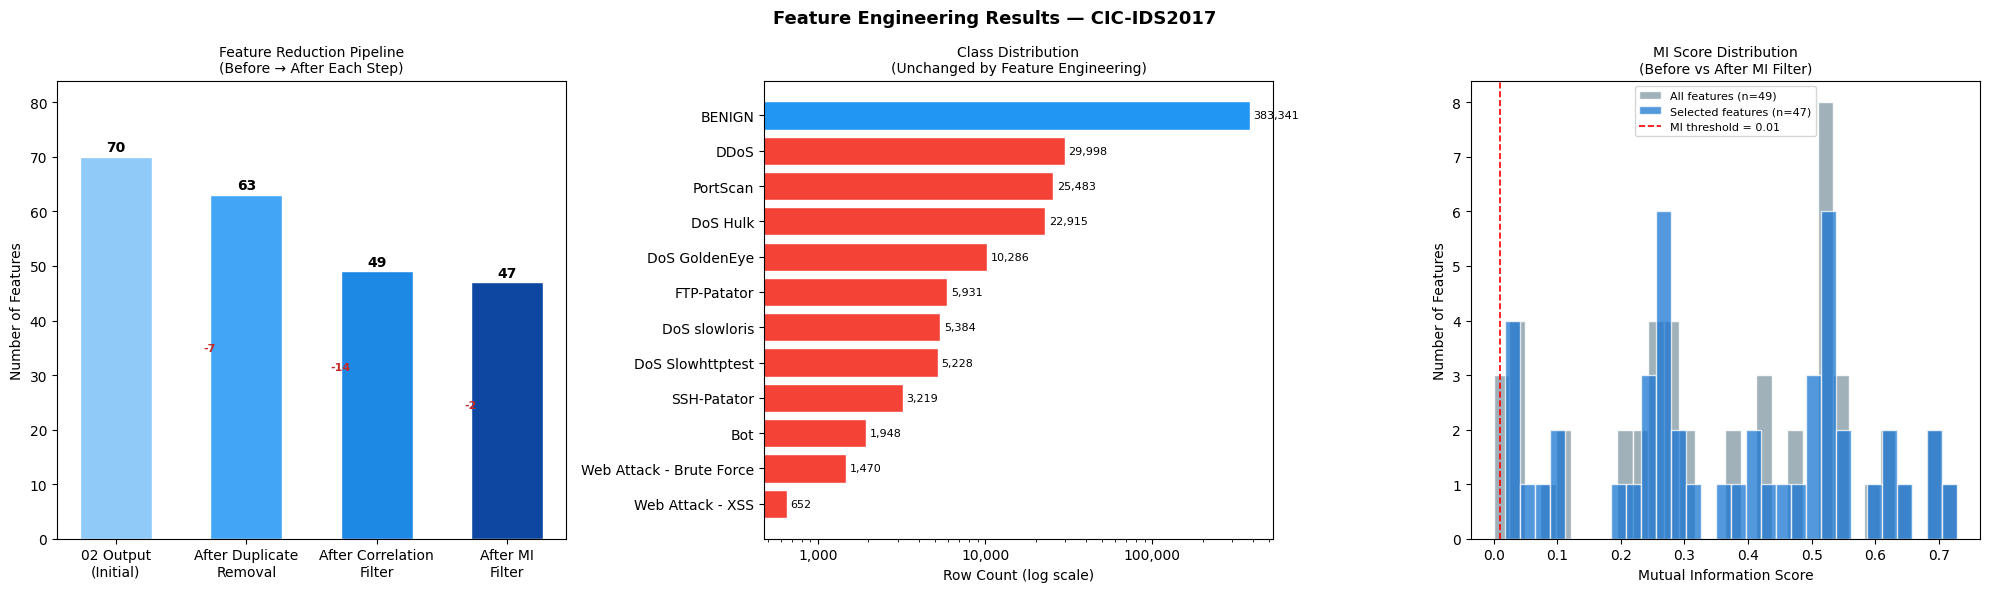

✓ Summary plot saved: ../data/plots/featured_distribution.png


In [14]:
# 8c. Before/After Summary: Feature Reduction Pipeline + Class Distribution + MI Distribution

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(
    "Feature Engineering Results — CIC-IDS2017",
    fontsize=13, fontweight="bold"
)

# ── Left: Feature Reduction Pipeline (Before → After each step) ─────────────
ax = axes[0]
steps       = ["02 Output\n(Initial)",
               "After Duplicate\nRemoval",
               "After Correlation\nFilter",
               "After MI\nFilter"]
step_counts = [n_features_initial, n_after_dup, n_after_corr, n_after_mi]
bar_colors  = ["#90CAF9", "#42A5F5", "#1E88E5", "#0D47A1"]
bars_p = ax.bar(steps, step_counts, color=bar_colors, edgecolor="white", width=0.55)

for bar, cnt in zip(bars_p, step_counts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            str(cnt), ha="center", va="bottom", fontsize=10, fontweight="bold")

# Arrows showing reduction
for i in range(len(step_counts) - 1):
    removed = step_counts[i] - step_counts[i + 1]
    if removed > 0:
        ax.annotate(
            f"-{removed}",
            xy=(i + 0.55, step_counts[i] / 2),
            xytext=(i + 0.72, step_counts[i] / 2),
            fontsize=8, color="#C62828", ha="center", va="center",
            fontweight="bold"
        )

ax.set_ylabel("Number of Features")
ax.set_title("Feature Reduction Pipeline\n(Before → After Each Step)", fontsize=10)
ax.set_ylim(0, max(step_counts) * 1.2)

# ── Middle: Class distribution after feature engineering ─────────────────────
ax = axes[1]
final_label_dist = df["Label"].value_counts()
labels_p  = final_label_dist.index.tolist()
counts_p  = final_label_dist.values.tolist()
colors_p  = ["#2196F3" if l == "BENIGN" else "#F44336" for l in labels_p]
bars2 = ax.barh(labels_p[::-1], counts_p[::-1], color=colors_p[::-1], edgecolor="white")
ax.set_xscale("log")
ax.set_xlabel("Row Count (log scale)")
ax.set_title("Class Distribution\n(Unchanged by Feature Engineering)", fontsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, cnt in zip(bars2, counts_p[::-1]):
    ax.text(bar.get_width() * 1.05, bar.get_y() + bar.get_height() / 2,
            f"{cnt:,}", va="center", ha="left", fontsize=8)

# ── Right: MI score distribution (all vs selected) ───────────────────────────
ax = axes[2]
ax.hist(mi_df["mi_score"], bins=30, color="#90A4AE",
        edgecolor="white", alpha=0.85, label=f"All features (n={len(mi_df)})")
ax.hist(mi_df_filtered["mi_score"], bins=30, color="#1976D2",
        edgecolor="white", alpha=0.75, label=f"Selected features (n={len(mi_df_filtered)})")
ax.axvline(MI_THRESHOLD, color="red", linestyle="--", linewidth=1.2,
           label=f"MI threshold = {MI_THRESHOLD}")
ax.set_xlabel("Mutual Information Score")
ax.set_ylabel("Number of Features")
ax.set_title("MI Score Distribution\n(Before vs After MI Filter)", fontsize=10)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/featured_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Summary plot saved: {PLOT_DIR}/featured_distribution.png")


## 8d. Model Performance — Before vs After Feature Engineering

**Purpose:** Validate that the reduced feature set does not sacrifice predictive power.
A lightweight Random Forest (50 trees, max_depth=10) is trained on a fixed
50 000-row stratified sample in two configurations:

| Configuration | Features used |
|---|---|
| **Before** | All numeric features from 02 output (no engineering) |
| **After** | Final selected features after duplicate/correlation/MI filters |

Metrics compared: Accuracy, F1-Macro, F1-Weighted, training time.
A significant drop in F1-Macro would indicate over-aggressive filtering.

Sample size : 50,000 rows
Before      : 70 features
After       : 47 features
Classes     : 12

Before (all features)
  Features   : 70
  Accuracy   : 0.9917
  F1-Macro   : 0.8544
  F1-Weighted: 0.9909
  Train time : 0.69s

After (selected features)
  Features   : 47
  Accuracy   : 0.9905
  F1-Macro   : 0.8498
  F1-Weighted: 0.9895
  Train time : 0.50s



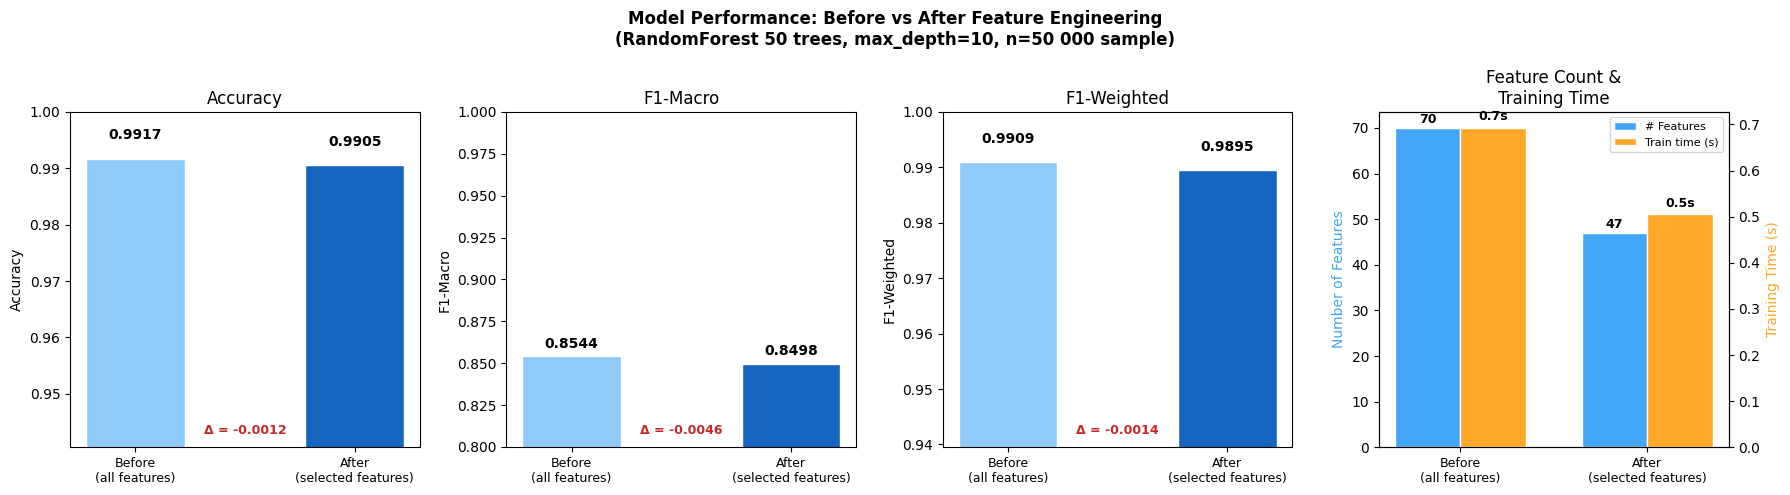

✓ Model comparison plot saved: ../data/plots/model_performance_before_after.png


In [15]:
# 8d. Model Performance — Before vs After Feature Engineering
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
import time

# ── Build after-sample using the SAME row indices ────────────────────────────
feature_cols_after = [c for c in df.select_dtypes(include=[np.number]).columns
                      if c not in ("label_multiclass", "label_binary")]
_X_after_sample = df[feature_cols_after].values[_sample_idx]
_y_sample       = df["label_multiclass"].values[_sample_idx]

print(f"Sample size : {len(_sample_idx):,} rows")
print(f"Before      : {_X_before_sample.shape[1]} features")
print(f"After       : {_X_after_sample.shape[1]} features")
print(f"Classes     : {len(np.unique(_y_sample))}")
print()

# ── Train & evaluate both configs ────────────────────────────────────────────
configs = [
    ("Before\n(all features)",      _X_before_sample, _n_features_all),
    ("After\n(selected features)",  _X_after_sample,  len(feature_cols_after)),
]

results = {}
for name, X, n_feat in configs:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, _y_sample, test_size=0.2,
        random_state=RANDOM_STATE, stratify=_y_sample
    )
    clf = RandomForestClassifier(
        n_estimators=50, max_depth=10,
        random_state=RANDOM_STATE, n_jobs=-1
    )
    t0 = time.time()
    clf.fit(X_tr, y_tr)
    train_time = time.time() - t0

    y_pred = clf.predict(X_te)
    results[name] = {
        "accuracy"   : accuracy_score(y_te, y_pred),
        "f1_macro"   : f1_score(y_te, y_pred, average="macro",    zero_division=0),
        "f1_weighted": f1_score(y_te, y_pred, average="weighted", zero_division=0),
        "n_features" : n_feat,
        "train_time" : train_time,
    }
    label_key = name.replace('\n', ' ')
    r = results[name]
    print(f"{label_key}")
    print(f"  Features   : {r['n_features']}")
    print(f"  Accuracy   : {r['accuracy']:.4f}")
    print(f"  F1-Macro   : {r['f1_macro']:.4f}")
    print(f"  F1-Weighted: {r['f1_weighted']:.4f}")
    print(f"  Train time : {r['train_time']:.2f}s")
    print()

# ── Plot: Before vs After comparison ─────────────────────────────────────────
labels_plot  = list(results.keys())
metrics      = ["accuracy", "f1_macro", "f1_weighted"]
metric_names = ["Accuracy", "F1-Macro", "F1-Weighted"]
colors_bar   = ["#90CAF9", "#1565C0"]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle(
    "Model Performance: Before vs After Feature Engineering\n"
    "(RandomForest 50 trees, max_depth=10, n=50 000 sample)",
    fontsize=12, fontweight="bold"
)

# Panels 1-3: metric bars ─────────────────────────────────────────────────────
for ax, metric, mname in zip(axes[:3], metrics, metric_names):
    vals = [results[k][metric] for k in labels_plot]
    bars = ax.bar(labels_plot, vals, color=colors_bar, edgecolor="white", width=0.45)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003,
                f"{val:.4f}", ha="center", va="bottom",
                fontsize=10, fontweight="bold")
    lo = min(vals) - 0.05
    ax.set_ylim(max(0, lo), 1.0)
    ax.set_ylabel(mname)
    ax.set_title(mname)
    ax.tick_params(axis='x', labelsize=9)

    # Delta annotation
    delta = vals[1] - vals[0]
    sign  = "+" if delta >= 0 else ""
    color = "#2E7D32" if delta >= 0 else "#C62828"
    ax.annotate(
        f"Δ = {sign}{delta:.4f}",
        xy=(0.5, 0.04), xycoords="axes fraction",
        ha="center", fontsize=9, color=color, fontweight="bold"
    )

# Panel 4: feature count + train time ────────────────────────────────────────
ax4 = axes[3]
feat_counts = [results[k]["n_features"] for k in labels_plot]
train_times = [results[k]["train_time"]  for k in labels_plot]

x = np.arange(len(labels_plot))
w = 0.35
ax4b = ax4.twinx()

b1 = ax4.bar(x - w/2, feat_counts, w, color="#42A5F5", edgecolor="white", label="# Features")
b2 = ax4b.bar(x + w/2, train_times, w, color="#FFA726", edgecolor="white", label="Train time (s)")

for bar, val in zip(b1, feat_counts):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(val), ha="center", va="bottom", fontsize=9, fontweight="bold")
for bar, val in zip(b2, train_times):
    ax4b.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
              f"{val:.1f}s", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax4.set_xticks(x)
ax4.set_xticklabels(labels_plot, fontsize=9)
ax4.set_ylabel("Number of Features", color="#42A5F5")
ax4b.set_ylabel("Training Time (s)",  color="#FFA726")
ax4.set_title("Feature Count &\nTraining Time")

lines1, labs1 = ax4.get_legend_handles_labels()
lines2, labs2 = ax4b.get_legend_handles_labels()
ax4.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/model_performance_before_after.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Model comparison plot saved: {PLOT_DIR}/model_performance_before_after.png")


## 9. Final Ozellik Seti Ozeti

In [16]:
feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in ("label_multiclass", "label_binary")]

print("=" * 65)
print("FINAL OZELLIK SETI OZETI")
print("=" * 65)
print(f"  Baslangic (02 ciktisi)           : {df.shape[1] - 3} numerik ozellik")
print(f"  Duplicate silme                  : bkz. Adim 2")
print(f"  Korelasyon filtresi (|r|>{CORR_THRESHOLD}) : bkz. Adim 3")
print(f"  MI filtresi (MI<{MI_THRESHOLD})           : bkz. Adim 5")
print(f"  FINAL numerik ozellik sayisi     : {len(feature_cols)}")
print()
print("Secilen ozellikler (MI sirasina gore):")
print(f"  {'#':<4} {'Ozellik':<45} {'MI Skoru':>10}")
print("-" * 62)
mi_ranked = mi_df[mi_df["feature"].isin(feature_cols)].sort_values("mi_score", ascending=False)
for rank, (_, row) in enumerate(mi_ranked.iterrows(), 1):
    print(f"  {rank:<4} {row['feature']:<45} {row['mi_score']:>10.4f}")

FINAL OZELLIK SETI OZETI
  Baslangic (02 ciktisi)           : 48 numerik ozellik
  Duplicate silme                  : bkz. Adim 2
  Korelasyon filtresi (|r|>0.98) : bkz. Adim 3
  MI filtresi (MI<0.01)           : bkz. Adim 5
  FINAL numerik ozellik sayisi     : 47

Secilen ozellikler (MI sirasina gore):
  #    Ozellik                                         MI Skoru
--------------------------------------------------------------
  1    Average Packet Size                               0.7282
  2    Packet Length Std                                 0.6983
  3    Packet Length Variance                            0.6972
  4    Subflow Fwd Bytes                                 0.6369
  5    Subflow Bwd Bytes                                 0.6290
  6    Avg Bwd Segment Size                              0.6260
  7    Fwd Packet Length Max                             0.5905
  8    Init_Win_bytes_backward                           0.5554
  9    Fwd IAT Total                                    

## 10. Kalite Kontrol

In [17]:
print("=" * 60)
print("KALITE KONTROL")
print("=" * 60)

# 1. NaN yok
assert df.isnull().sum().sum() == 0, "HATA: NaN var!"
print("v NaN yok")

# 2. Inf yok
num_check = df.select_dtypes(include=[np.number]).columns
assert not np.isinf(df[num_check].values).any(), "HATA: Inf var!"
print("v Inf yok")

# 3. Sifir-varyans sUtun yok
zv = [c for c in feature_cols if df[c].nunique() <= 1]
assert len(zv) == 0, f"HATA: Sifir-varyans sutun var: {zv}"
print("v Sifir-varyans sutun yok")

# 4. label_multiclass ve label_binary tutarli
n_mc = df["label_multiclass"].nunique()
n_lb = df["label_binary"].nunique()
assert n_mc >= 2, f"HATA: Multiclass label tek deger: {n_mc}"
assert n_lb == 2, f"HATA: Binary label 2 deger icermeli: {n_lb}"
print(f"v label_multiclass: {n_mc} sinif")
print(f"v label_binary: 2 sinif")

# 5. Label string ile LabelEncoder tutarli
assert set(df["Label"].unique()) == set(le.classes_), \
    "HATA: Label string ile LabelEncoder siniflari uyusmuyor!"
print("v Label string <-> label_multiclass tutarli")

# 6. Ozellik sayisi makul (10-100 arasi beklenir)
assert 10 <= len(feature_cols) <= 100, \
    f"HATA: Ozellik sayisi beklenen aralik disinda: {len(feature_cols)}"
print(f"v Ozellik sayisi makul: {len(feature_cols)}")

# 7. Yuksek korelasyon kalmamali
corr_check = df[feature_cols].corr().abs()
upper_check = corr_check.where(
    np.triu(np.ones(corr_check.shape), k=1).astype(bool)
)
max_remaining_corr = upper_check.max().max()
if max_remaining_corr > CORR_THRESHOLD + 0.005:
    print(f"! Uyari: Hala yuksek korelasyon var: {max_remaining_corr:.4f}")
else:
    print(f"v Maksimum kalan korelasyon: {max_remaining_corr:.4f}")

# 8. Benign orani makul
total = len(df)
n_b   = (df["label_binary"] == 0).sum()
benign_pct = n_b / total * 100
assert 40 <= benign_pct <= 90, f"HATA: Benign orani anormal -> %{benign_pct:.1f}"
print(f"v Benign orani makul: %{benign_pct:.1f}")

print()
print("=" * 60)
print("OZET")
print("=" * 60)
print(f"  Satir          : {total:>9,}")
print(f"  Ozellik sayisi : {len(feature_cols)}")
print(f"  Sinif sayisi   : {n_mc}")
print(f"  Benign orani   : %{benign_pct:.1f}")
print()
print("=" * 60)
print("DATASET HAZIR -> sonraki adim: 04_modeling.ipynb")
print("=" * 60)

KALITE KONTROL
v NaN yok
v Inf yok
v Sifir-varyans sutun yok
v label_multiclass: 12 sinif
v label_binary: 2 sinif
v Label string <-> label_multiclass tutarli
v Ozellik sayisi makul: 47
v Maksimum kalan korelasyon: 0.9793
v Benign orani makul: %77.3

OZET
  Satir          :   495,855
  Ozellik sayisi : 47
  Sinif sayisi   : 12
  Benign orani   : %77.3

DATASET HAZIR -> sonraki adim: 04_modeling.ipynb


## 11. Kaydetme

In [18]:
# 1. Ana dataset (secilmis feature + label sutunlari)
cols_to_save = feature_cols + ["Label", "label_multiclass", "label_binary"]
if "source_file" in df.columns:
    cols_to_save.append("source_file")

df[cols_to_save].to_csv(OUTPUT_DATASET, index=False)
size_mb = os.path.getsize(OUTPUT_DATASET) / (1024 * 1024)
print(f"v Featured dataset kaydedildi : {OUTPUT_DATASET}")
print(f"  Boyut  : {size_mb:.1f} MB")
print(f"  Satir  : {len(df):,}")
print(f"  Sutun  : {len(cols_to_save)}")

# 2. Ozellik listesi (04_modeling'de dogrudan import icin)
with open(OUTPUT_FEATURES_TXT, "w") as f_out:
    for feat in sorted(feature_cols):
        f_out.write(feat + "\n")
print(f"\nv Ozellik listesi kaydedildi  : {OUTPUT_FEATURES_TXT}")
print(f"  {len(feature_cols)} ozellik")

# 3. Label esleme tablosu
label_mapping.to_csv(OUTPUT_LABEL_MAP, index=False)
print(f"\nv Label esleme tablosu        : {OUTPUT_LABEL_MAP}")
print()
print(label_mapping.to_string(index=False))

v Featured dataset kaydedildi : ../data/csv/featured_dataset.csv
  Boyut  : 139.6 MB
  Satir  : 495,855
  Sutun  : 51

v Ozellik listesi kaydedildi  : ../data/csv/selected_features.txt
  47 ozellik

v Label esleme tablosu        : ../data/csv/label_mapping.csv

 label_int             label_string
         0                   BENIGN
         1                      Bot
         2                     DDoS
         3            DoS GoldenEye
         4                 DoS Hulk
         5         DoS Slowhttptest
         6            DoS slowloris
         7              FTP-Patator
         8                 PortScan
         9              SSH-Patator
        10 Web Attack - Brute Force
        11         Web Attack - XSS
